In [41]:
import pandas as pd
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# imports
import matplotlib.pyplot as plt, numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize'] = (12, 6)

In [42]:
# ## 1. Problem formulation
# Find clusters

In [43]:
# 2. Data collection
df = pd.read_csv("iris.csv")
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [44]:
# 3. Data labelling
# This is unsupervised learning, so data lebelling is not required here.

In [45]:
# 4. EDA

# lets look at the columns data types
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None


In [46]:
# lets look at the common statistics
print(df.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


In [47]:
## more EDA can be done here, like plotting scatter plot between all pairs

In [48]:
# Feature selection (assuming all columns except 'id' are relevant)
features = df.drop(['target'], axis=1).to_numpy()  # keep all columns except target columns
print(features)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [49]:
# Scale the features for better clustering performance
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [50]:
print(f"First 10 scaled features: \n{scaled_features[:10]}")
print("########################")

## OR you can look at unscaled/scaled feature side-by-side
print(features[0], "------>", scaled_features[0])
print(features[1], "------>", scaled_features[1])


First 10 scaled features: 
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]
 [-0.53717756  1.93979142 -1.16971425 -1.05217993]
 [-1.50652052  0.78880759 -1.34022653 -1.18381211]
 [-1.02184904  0.78880759 -1.2833891  -1.3154443 ]
 [-1.74885626 -0.36217625 -1.34022653 -1.3154443 ]
 [-1.14301691  0.09821729 -1.2833891  -1.44707648]]
########################
[5.1 3.5 1.4 0.2] ------> [-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
[4.9 3.  1.4 0.2] ------> [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]


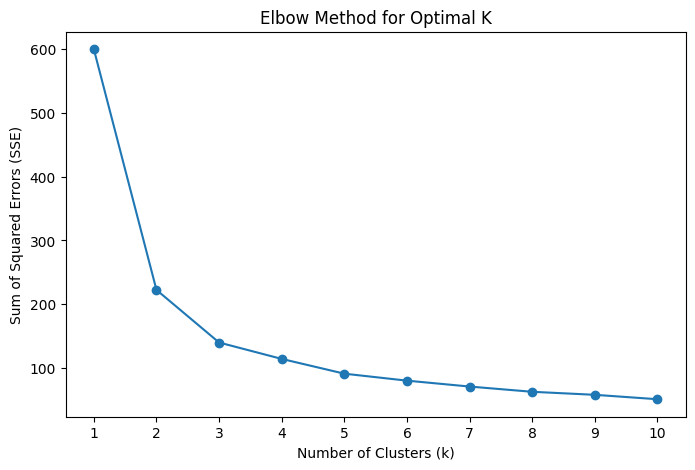

In [51]:
# Elbow method to determine the optimal K
kmeans_kwargs = {
    "init": "random",
    "n_init": 10,
    "max_iter": 300,
    "random_state": 42,
}

# A list holds the SSE values for each k
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_features)
    sse.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), sse, marker='o', linestyle='-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.title("Elbow Method for Optimal K")
plt.xticks(range(1, 11))
plt.show()

In [52]:
# We see from above that K=3, is the optimal

# Apply KMeans clustering (K=3) with scaling
kmeans_with_scaling = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_with_scaling = kmeans_with_scaling.fit_predict(scaled_features)

# Add cluster labels to the DataFrame
df["Cluster_With_Scaling"] = clusters_with_scaling

# Print cluster centers (scaled)
print("Cluster Centers (With Scaling - Standardized Features):")
print(kmeans_with_scaling.cluster_centers_)

Cluster Centers (With Scaling - Standardized Features):
[[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]


In [53]:
# lets print the cluster labels of the few points
print(kmeans_with_scaling.labels_[:10])

[1 1 1 1 1 1 1 1 1 1]


In [54]:
print(df)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

     target  Cluster_With_S

In [55]:
# Lets see how many clusters and their corresponding counts
import numpy as np
unique, counts = np.unique(kmeans_with_scaling.labels_, return_counts=True)

print(unique)
print(counts)

[0 1 2]
[53 50 47]


In [56]:
# Lets zip above and put them in dictionary: key=cluster-label : value=count on how many belong to each clusters
dict_data = dict(zip(unique, counts))
print(dict_data)

{0: 53, 1: 50, 2: 47}


In [57]:
# KMeans assigns cluster labels arbitrarily. That means Cluster 0 doesn’t necessarily
# correspond to Class 0 — but that’s totally fine.

# You don't fix KMeans labels directly, but you relabel the clusters to best match 
# the actual classes using a mapping based on the majority vote within each cluster.

import numpy as np
from scipy.stats import mode

# Create an empty mapping
label_mapping = {}

# For each cluster label, find the most common actual target label
for i in range(3):
    # Find rows where the cluster label is equal to i
    mask = df['Cluster_With_Scaling'] == i
    print(f"\nCluster {i} contains {mask.sum()} samples.")

    # Extract the actual class labels (target values) of these rows
    actual_targets = df[mask]['target']
    print(f"Actual class distribution in cluster {i}:\n{actual_targets.value_counts().to_string()}")

    # Find the most common actual target (majority class) in this cluster
    most_common = mode(actual_targets, keepdims=True).mode[0]
    print(f"Most common target in cluster {i}: {most_common}")

    # Add to the mapping
    label_mapping[i] = most_common


print("Cluster-to-Class Mapping:", label_mapping)
print(f"df.head(150):\n{df.head(150)}")

# Map KMeans cluster labels to target labels
df['Cluster_Mapped'] = df['Cluster_With_Scaling'].map(label_mapping)




Cluster 0 contains 53 samples.
Actual class distribution in cluster 0:
target
1    39
2    14
Most common target in cluster 0: 1

Cluster 1 contains 50 samples.
Actual class distribution in cluster 1:
target
0    50
Most common target in cluster 1: 0

Cluster 2 contains 47 samples.
Actual class distribution in cluster 2:
target
2    36
1    11
Most common target in cluster 2: 2
Cluster-to-Class Mapping: {0: 1, 1: 0, 2: 2}
df.head(150):
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...              

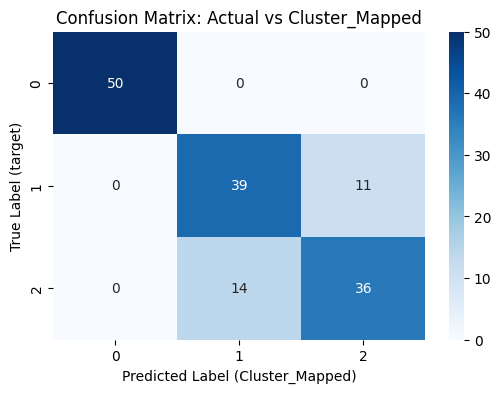

In [58]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(df['target'], df['Cluster_Mapped'])

# Plot it
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2], yticklabels=[0,1,2])

plt.xlabel('Predicted Label (Cluster_Mapped)')
plt.ylabel('True Label (target)')
plt.title('Confusion Matrix: Actual vs Cluster_Mapped')
plt.show()

In [59]:
# Now compare
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(df['target'], df['Cluster_Mapped'])
print("Accuracy after mapping:", accuracy)


Accuracy after mapping: 0.8333333333333334


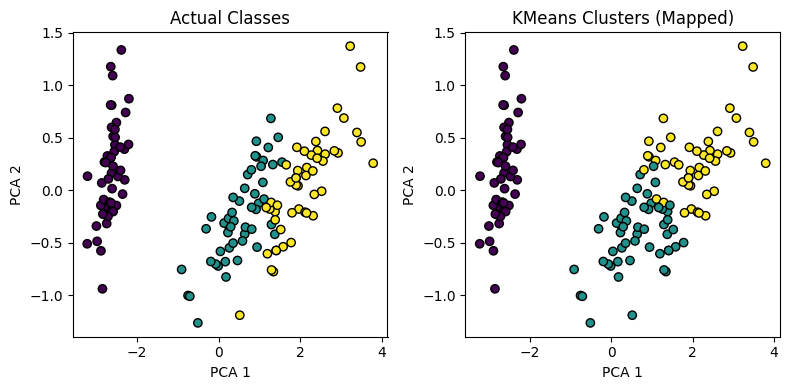

In [60]:
# Now lets reduce the dim to 2 using PCA. Then plot the actual classes and the Kmeans clusters with the labels
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(df.drop(['target', 'Cluster_With_Scaling', 'Cluster_Mapped'], axis=1))

plt.figure(figsize=(8,4))

# Actual classes
plt.subplot(1, 2, 1)
plt.scatter(reduced[:,0], reduced[:,1], c=df['target'], cmap='viridis', edgecolor='k')
plt.title("Actual Classes")
plt.xlabel("PCA 1"); plt.ylabel("PCA 2")

# Mapped Clusters
plt.subplot(1, 2, 2)
plt.scatter(reduced[:,0], reduced[:,1], c=df['Cluster_Mapped'], cmap='viridis', edgecolor='k')
plt.title("KMeans Clusters (Mapped)")
plt.xlabel("PCA 1"); plt.ylabel("PCA 2")

plt.tight_layout()
plt.show()


## observation:
# The actual clusters almost match kmeans clusters. 

In [61]:
# Now lets measure the performance of our kmeans clustersing
# 1) silhouette_score:
# - Measures how well each point lies within its cluster
# - Considers cohesion (how close points in a cluster are) and separation (how far clusters are from each other)

# Range: -1 to 1
# 1 = well-clustered
# 0 = overlapping clusters
# <0 = bad clustering



from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_features, clusters_with_scaling)
print(f"Silhouette Score: {score:.3f}")


Silhouette Score: 0.460


In [62]:
# 2. Inertia (Within-Cluster Sum of Squares)
# - Comes directly from KMeans
# - Measures how tight the clusters are
# - Lower is better, but it always decreases with more clusters — so not a great standalone metric

print(f"Inertia (WCSS): {kmeans_with_scaling.inertia_}")


Inertia (WCSS): 139.8204963597497
